### Cell instance segmentation and phenotyping
In this notebook, we demonstrate how the (frozen) VirTues-M2 embeddings can be leveraged to generate both instance and semantic cell segmentation masks in one go.

For this, we use a CellViT and instanseg alike segmentation decoder. To combine the knowledge of both modalities, we concatenate the modality-wise patch tokens along the feature dimension and pass them to the decoder. This happens after tokenization, and after the 6th, 12th, 18th and the last (24th) layer of the transformer encoder of VirTues-M2.

In [ ]:
import sys
sys.path.append('..')

import numpy as np
import torch
from matplotlib.patches import Patch
from torchvision import transforms
import matplotlib.pyplot as plt

from virtuesm2.models.virtuesm2_hf import VirTuesM2_HF
from virtuesm2.segmentation.decoder_hf import VM2_Segmentation_HF
from virtuesm2.utils.utils import load_marker_embedding_dict
from virtuesm2.segmentation.utils import assign_cell_types, CELL_TYPE_MAPPING, CELL_TYPE_COLOR_MAP

from spora_io import ComposedImagingDataset

# if jupyter cannot read the spora datasets dir from your environment, you can set it here:
# import os
# os.environ["SPORA_DATASETS_DIR"] = "..."

/mnt/aimm/scratch/querfurth/code/virtues-world/virtues-m2/virtuesm2/models/layers/swiglu_ffn.py:38: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/mnt/aimm/scratch/querfurth/code/virtues-world/virtues-m2/virtuesm2/models/layers/attention_qkv_separate.py:17: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
2026-09-07 14:47:40.036 | INFO     | virtuesm2.models.layers:<module>:22 - Using xformers version 0.0.29.post3 for attention layers.


In [2]:
from matplotlib.colors import ListedColormap, BoundaryNorm
colors = [CELL_TYPE_COLOR_MAP.get(name, "#DDDDDD") for name in list(CELL_TYPE_MAPPING.keys())]
cmap = ListedColormap(colors)
norm = BoundaryNorm(range(len(CELL_TYPE_MAPPING) + 1), cmap.N)

#### Load the multiplex and H&E sample crop

In [7]:
undo_he_norm = transforms.Compose([
    transforms.Normalize(mean=[0., 0., 0.], std=[1/0.195, 1/0.2316, 1/0.1816]),
    transforms.Normalize(mean=[-0.7068, -0.5755, -0.722], std=[1., 1., 1.]),
])

ds = ComposedImagingDataset(
    name="lin2023high",
    modalities=["he", "cycif"],
    tile_size=224,
    resolution=1.0,
    tile_strategy="default",
    modality_kwargs={
        "codex":   {"standardization": "quantile_clipping/uq_0.99_image", "use_mean_std": False, "filter_list": ["gaussian_blur"], "replace_nuclear_uniprot_ids": True},
        "cycif":   {"standardization": "quantile_clipping/uq_0.99_image", "use_mean_std": False, "filter_list": ["gaussian_blur"], "replace_nuclear_uniprot_ids": True},
        "he"   :   {"mean_std_type"  : "hibou"},
    },

)

tissue_id = "lin2023high_zupwxfxb_0000" # coords of example crop: (14648, 20745)
he_sample = ds.get_dataset("he").get_tile_by_coordinates(tissue_id, row=14648, col=20745)
mx_sample = ds.get_dataset("cycif").get_tile_by_coordinates(tissue_id, row=14648, col=20745)

2026-09-07 14:49:33.206 | INFO     | spora_io.utils.utils:print_verbose:26 - Initializing modality 'he'...
2026-09-07 14:49:33.216 | INFO     | spora_io.utils.utils:print_verbose:26 - Initializing modality 'cycif'...
2026-09-07 14:49:33.225 | INFO     | spora_io.utils.utils:print_verbose:26 - Replaced UniProt IDs for 1 nuclear channels with P68431.
2026-09-07 14:49:33.228 | INFO     | spora_io.utils.utils:print_verbose:26 - Using image-channel map from /mnt/aimm/scratch/datasets_v2/lin2023high/cycif/channels_per_tissue.parquet
2026-09-07 14:49:33.231 | INFO     | spora_io.utils.dataset.standardize:__init__:192 - Loaded standardization stats 'quantile_clipping/uq_0.99_image' from /mnt/aimm/scratch/datasets_v2/lin2023high/cycif/1_0mpp/standardization/quantile_clipping/uq_0.99_image (quantile_level=image, stats_level=global, use_mean_std=False)
2026-09-07 14:49:33.232 | INFO     | spora_io.utils.utils:print_verbose:26 - Using Multiplex standardization: QuantileClippingStandardizer
2026-09

Filters to apply: ['gaussian_blur']


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

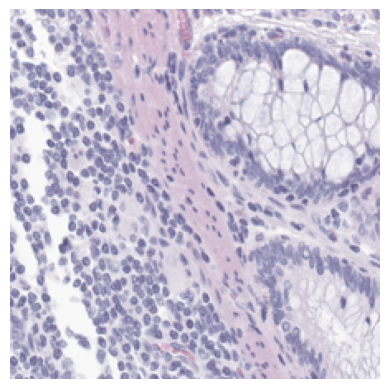

In [8]:
# mx_image = sample["modalities"]["cycif"].image
# he_image = sample["modalities"]["he"].image
# marker_names = sample["modalities"]["cycif"].channel_names
# uniprot_ids = sample["modalities"]["cycif"].uniprot_ids

mx_image = mx_sample.image
he_image = he_sample.image
marker_names = mx_sample.channel_names
uniprot_ids = mx_sample.uniprot_ids

he_image_raw = undo_he_norm(he_image).permute(1, 2, 0).numpy()
he_image_raw = np.clip(he_image_raw, 0, 1)
plt.imshow(he_image_raw)
plt.axis("off")


#### Load ESM-2 embeddings

In [9]:
esm_embeddings = load_marker_embedding_dict("../example_data/esm_embeddings")
uniprot_indices = torch.tensor([esm_embeddings[uniprot_id] for uniprot_id in uniprot_ids])

#### Create Model

In [10]:
# Initialize the model from Hugging Face Hub
model = VirTuesM2_HF.from_pretrained("bunnelab/virtues-m2", marker_embedding_dir="../example_data/esm_embeddings", revision="v2")
segmentation_model = VM2_Segmentation_HF.from_pretrained("bunnelab/virtues-m2", virtuesm2_model=model ,revision="v2")

segmentation_model.cuda()
segmentation_model.eval()

VM2_Segmentation_HF(
  (virtuesm2_model): VirTuesM2_HF(
    (he_embed_layer): PatchEmbed(
      (proj): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14))
      (norm): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
    )
    (mx_embed_layer): MultiplexTokenizer(
      (protein_encoder): Linear(in_features=640, out_features=1024, bias=True)
      (multiplex_patch_encoder): Linear(in_features=196, out_features=1024, bias=True)
      (layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (encoder): ModuleList(
        (0): MarkerAttentionEncoderBlock(
          (encoder_layer): TransformerEncoder(
            (layers): ModuleList(
              (0-1): 2 x TransformerEncoderBlock(
                (multi_head_attention): MHAwithPosEmb(
                  (W_q): Linear(in_features=1024, out_features=1024, bias=True)
                  (W_k): Linear(in_features=1024, out_features=1024, bias=True)
                  (W_v): Linear(in_features=1024, out_features=102

#### Forward pass through VirTues-M2 + Segmentation Decoder

In [11]:
mx_image = mx_image.cuda()
he_image = he_image.cuda()
uniprot_ids = uniprot_indices.cuda()
inst_pred, sem_pred = segmentation_model.segment_tissue(mx_image, he_image, uniprot_indices, tile_size=224, overlap=16, batch_size=16)

sem_pred[CELL_TYPE_MAPPING["Unknown"]] = -float("inf")
sem_pred[CELL_TYPE_MAPPING["None"]] = -float("inf")
sem_pred = sem_pred.argmax(dim=0)

inst_pred = inst_pred.cpu().numpy()
sem_pred = sem_pred.cpu().numpy()

sem_pred_instances = assign_cell_types(inst_pred, sem_pred)

100%|██████████| 1/1 [00:00<00:00,  2.15it/s]


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

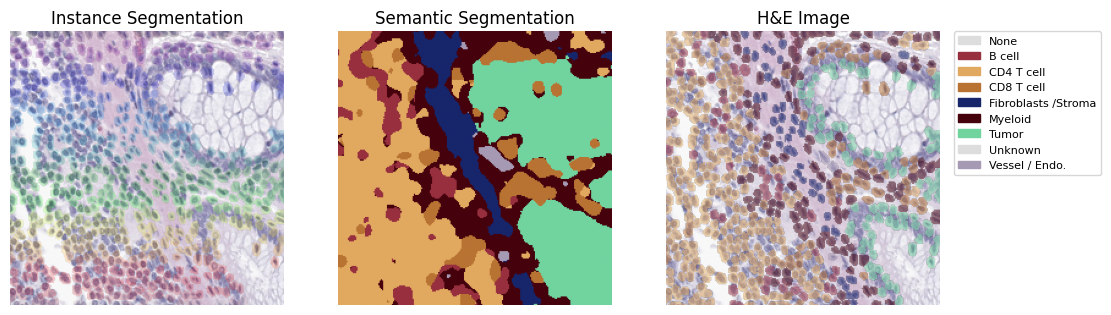

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(12, 6))
axs = axs.flatten()

inst_pred = inst_pred.astype(float)
inst_pred[inst_pred == 0] = np.nan

axs[0].imshow(he_image_raw)
axs[0].imshow(inst_pred, cmap="nipy_spectral", alpha=0.2)
axs[0].set_title("Instance Segmentation")
axs[0].axis("off")

axs[1].imshow(sem_pred, cmap=cmap, norm=norm)
axs[1].set_title("Semantic Segmentation")
axs[1].axis("off")

# convolved with semantic segmentation
axs[2].imshow(he_image_raw)
axs[2].imshow(sem_pred_instances, alpha=0.5, cmap=cmap, norm=norm)
patches = [Patch(color=CELL_TYPE_COLOR_MAP.get(name, "#DDDDDD"), label=name) for name in list(CELL_TYPE_MAPPING.keys())]
axs[2].legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=8)
axs[2].set_title("H&E Image")
axs[2].axis("off")